# 02 — Correlation Analysis

Pearson correlation between medical and sports facilities, heatmap of all covariates (Section 4.2).

[OVERALL] n=2629921, r=0.6118, 95% CI [0.6111, 0.6126], p=0
    year       n  pearson_r  p_value    CI_low   CI_high
0   2012  218952   0.538679      0.0  0.535699  0.541645
1   2013  219238   0.552147      0.0  0.549230  0.555050
2   2014  219098   0.572205      0.0  0.569382  0.575015
3   2015  219098   0.588160      0.0  0.585415  0.590893
4   2016  219099   0.600534      0.0  0.597850  0.603204
5   2017  219099   0.602886      0.0  0.600214  0.605545
6   2018  219099   0.612861      0.0  0.610240  0.615469
7   2019  219099   0.618193      0.0  0.615600  0.620774
8   2020  219099   0.621912      0.0  0.619338  0.624473
9   2021  219099   0.631401      0.0  0.628877  0.633913
10  2022  219100   0.634036      0.0  0.631525  0.636533
11  2023  219841   0.638800      0.0  0.636319  0.641268


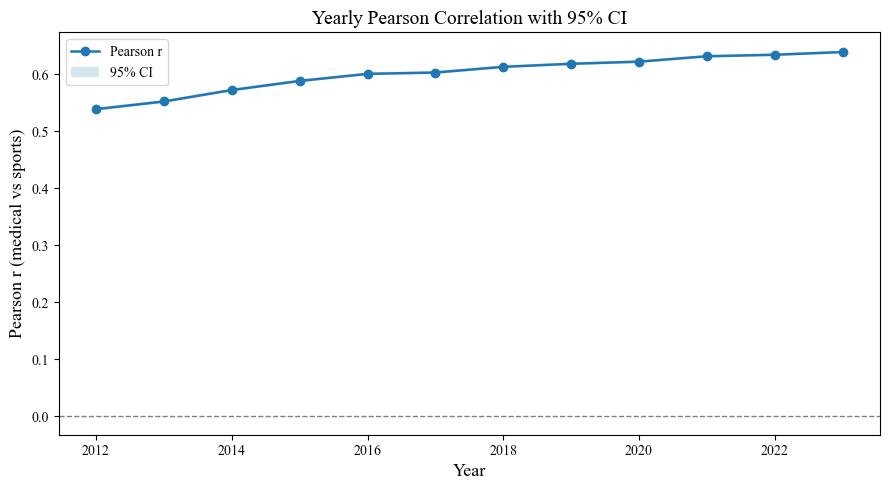

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"

# ========================================
# 1) Load data
# ========================================
INFILE = "jiangxi_causal_forest_panel_1km_with_city.csv"
OUTDIR = "correlation_outputs"
os.makedirs(OUTDIR, exist_ok=True)

df = pd.read_csv(INFILE, encoding="utf-8-sig")
if "is_water" in df.columns:
    df = df[df["is_water"] != 1].copy()
df["year"] = df["year"].astype(int)

XVAR = "sports_cnt"
YVAR = "medical_cnt"

# ========================================
# 2) Pearson correlation: overall and by year
# ========================================
def safe_pearson(x, y):
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    n = int(mask.sum())
    if n < 2 or x.std(ddof=1) == 0 or y.std(ddof=1) == 0:
        return np.nan, np.nan, n
    r, p = pearsonr(x, y)
    return float(r), float(p), n

def fisher_ci(r, n, alpha=0.05):
    if not np.isfinite(r) or n < 4 or abs(r) >= 1:
        return np.nan, np.nan
    z = 0.5 * np.log((1 + r) / (1 - r))
    se = 1.0 / np.sqrt(n - 3)
    lo = z - 1.96 * se
    hi = z + 1.96 * se
    return np.tanh(lo), np.tanh(hi)

# Overall
r_all, p_all, n_all = safe_pearson(df[XVAR], df[YVAR])
ci_lo, ci_hi = fisher_ci(r_all, n_all)
print(f"[OVERALL] n={n_all}, r={r_all:.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}], p={p_all:.3g}")

# By year
rows = []
for yr, sub in df.groupby("year"):
    r, p, n = safe_pearson(sub[XVAR], sub[YVAR])
    lo, hi = fisher_ci(r, n)
    rows.append({"year": int(yr), "n": n, "pearson_r": r, "p_value": p, "CI_low": lo, "CI_high": hi})
res_year = pd.DataFrame(rows).sort_values("year")
res_year.to_csv(os.path.join(OUTDIR, "pearson_by_year.csv"), index=False, encoding="utf-8-sig")
print(res_year)

# ========================================
# 3) Plot: Yearly Pearson r with 95% CI
# ========================================
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(res_year["year"], res_year["pearson_r"], marker="o", linewidth=1.8, label="Pearson r")
ax.fill_between(res_year["year"], res_year["CI_low"], res_year["CI_high"], alpha=0.18, label="95% CI")
ax.axhline(0, linestyle="--", linewidth=1, color="gray")
ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Pearson r (medical vs sports)", fontsize=13)
ax.set_title("Yearly Pearson Correlation with 95% CI", fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "pearson_yearly.png"), dpi=300)
plt.show()


## Correlation Heatmap (All Covariates)

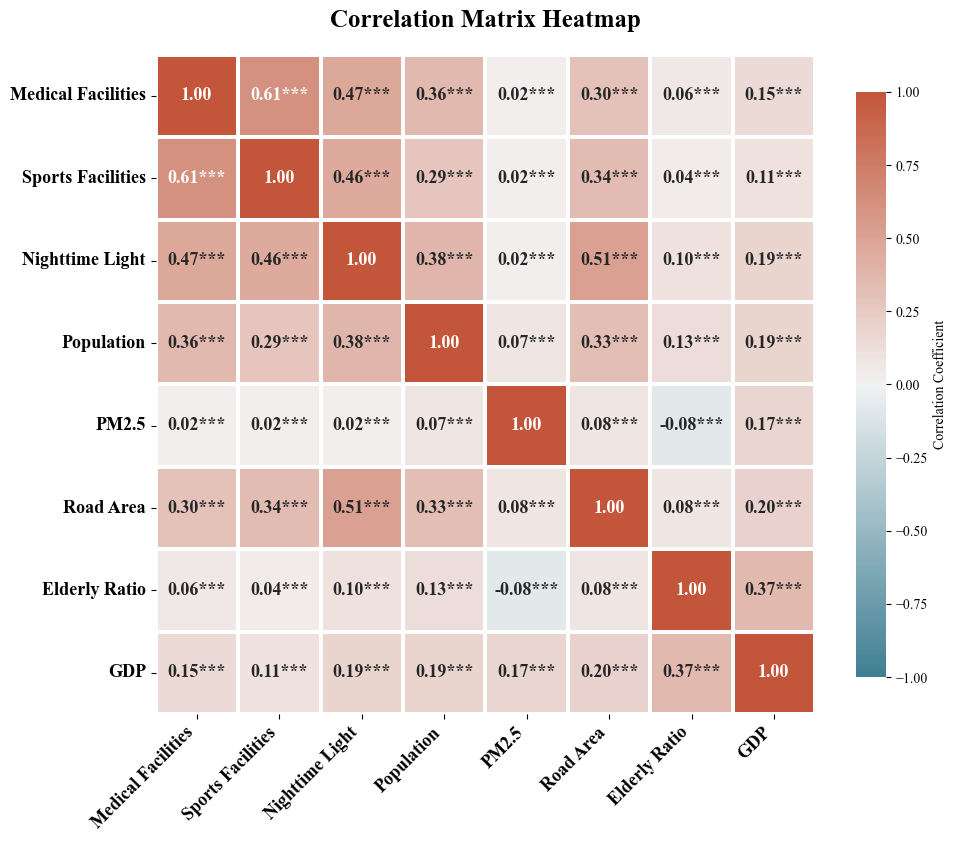

Saved: correlation_outputs/heatmap.png


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.rcParams["font.family"] = "Times New Roman"

col_map = {
    "medical_cnt": "Medical Facilities",
    "sports_cnt": "Sports Facilities",
    "ntl": "Nighttime Light",
    "pop": "Population",
    "PM25": "PM2.5",
    "road": "Road Area",
    "aging_rate": "Elderly Ratio",
    "GDP_log": "GDP"
}
selected_columns = list(col_map.keys())

df = pd.read_csv("jiangxi_causal_forest_panel_1km_with_city.csv", encoding="utf-8-sig")
if "is_water" in df.columns:
    df = df[df["is_water"] != 1].copy()
df = df[selected_columns].apply(pd.to_numeric, errors="coerce")
corr_matrix = df.corr(method="pearson")

# Compute significance stars
labels = []
for i, row in enumerate(selected_columns):
    row_labels = []
    for j, col in enumerate(selected_columns):
        if i == j:
            row_labels.append(f"{corr_matrix.iloc[i, j]:.2f}")
        else:
            x, y = df[row].values, df[col].values
            mask = np.isfinite(x) & np.isfinite(y)
            n = int(mask.sum())
            if n < 3 or np.std(x[mask], ddof=1) == 0:
                r, p = np.nan, np.nan
            else:
                r, p = pearsonr(x[mask], y[mask])
            star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
            row_labels.append(f"{(0 if np.isnan(r) else r):.2f}{star}")
    labels.append(row_labels)

plt.figure(figsize=(10, 9))
sns.heatmap(
    corr_matrix.rename(index=col_map, columns=col_map),
    annot=np.array(labels), fmt="", cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1, vmax=1, center=0, square=True, linewidths=1.5, linecolor="white",
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"},
    annot_kws={"size": 13, "weight": "bold", "family": "Times New Roman"}
)
plt.xticks(fontsize=13, rotation=45, ha="right", weight="bold")
plt.yticks(fontsize=13, rotation=0, weight="bold")
plt.title("Correlation Matrix Heatmap", fontsize=18, weight="bold", pad=20)
plt.tight_layout()
plt.savefig("correlation_outputs/heatmap.png", dpi=300)
plt.show()
print("Saved: correlation_outputs/heatmap.png")
